# Exploratory Data Analysis (EDA): Recruit Restaurant Visitor Forecasting



## 1. Environment Setup & Data Loading
### Importing required libraries, setting up the environment, and loading the raw datasets.

In [62]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from IPython.display import display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
from pathlib import Path

from restaurant_visitor_eda.config import RAW_DATA_DIR



dfs = {f.stem: pd.read_csv(f) for f in RAW_DATA_DIR.glob("*.csv")}
print(f"Loaded tables: {list(dfs.keys())}")

Loaded tables: ['hpg_store_info', 'sample_submission', 'store_id_relation', 'air_visit_data', 'date_info', 'hpg_reserve', 'air_reserve', 'air_store_info']


In [64]:
df_air_reserve = dfs['air_reserve']
df_air_store_info = dfs['air_store_info']
df_air_visit_data = dfs['air_visit_data']
df_date_info = dfs['date_info']
df_hpg_reserve = dfs['hpg_reserve']
df_hpg_store_info = dfs['hpg_store_info']
df_store_id_relation = dfs['store_id_relation']

## 2. High-Level Data Overview
### Checking for missing values (NaNs) and unique values


In [65]:
from restaurant_visitor_eda.dataset import count_unique_and_nans

for name, df in dfs.items():
    print(name)
    stats = count_unique_and_nans(df)
    display(stats.style
        .format({"nan percentage": "{:.2f}%"})
        .background_gradient(cmap='Reds', subset=['nan percentage'])
    )

hpg_store_info


,nan percentage,unique
hpg_store_id,0.00%,4690
hpg_genre_name,0.00%,34
hpg_area_name,0.00%,119
latitude,0.00%,129
longitude,0.00%,129


sample_submission


,nan percentage,unique
id,0.00%,32019
visitors,0.00%,1


store_id_relation


...

,nan percentage,unique
hpg_store_id,0.00%,13325
visit_datetime,0.00%,9847
reserve_datetime,0.00%,11450
reserve_visitors,0.00%,99


air_reserve


,nan percentage,unique
air_store_id,0.00%,314
visit_datetime,0.00%,4975
reserve_datetime,0.00%,7513
reserve_visitors,0.00%,71


air_store_info


,nan percentage,unique
air_store_id,0.00%,829
air_genre_name,0.00%,14
air_area_name,0.00%,103
latitude,0.00%,108
longitude,0.00%,108


#### Exploring ``air_reserve`` and `` air_store_id`` relationship


In [66]:
check_merge = pd.merge(
    df_air_reserve[['air_store_id']].drop_duplicates(),
    df_air_store_info[['air_store_id']], 
    on='air_store_id', 
    how='left', 
    indicator=True
)

missing_count = (check_merge['_merge'] == 'left_only').sum()

print(f"Restaurants in reservations but missing in info: {missing_count}")

Restaurants in reservations but missing in info: 0


### Key Insights: 

1. **Hidden risk:** Despite the fact there are exactly **0** NaNs across all given tables in the data set, we can surely say that a lot of information is missing logically and structurally rather than as having **null** values.

2. **Partial Reservation Coverage (AIR):** The `air_store_info` table contains **829** unique restaurants, but only **314** of them have reservation records in the `air_reserve` table. We have verified via a merge integrity check that all 314 restaurants from the reservation records exist in the master info table. This tells us that we do not have any information about reserves made in **829 - 314 = 515** **(62% of the data set)** restaurants through **AIR** service.

3. **Weak AIR-HPG linkage:** The `store_id_relation` table has only **150** rows. Thus, we can effectiely use info from `hpg_*` tables only for **150** restaurants, which is significantly less than the total number of restaurants in both **AIR** and **HPG** systems.

## 3. Target Value (`visitors`)

### Target value distribution: (given and logarithmized)

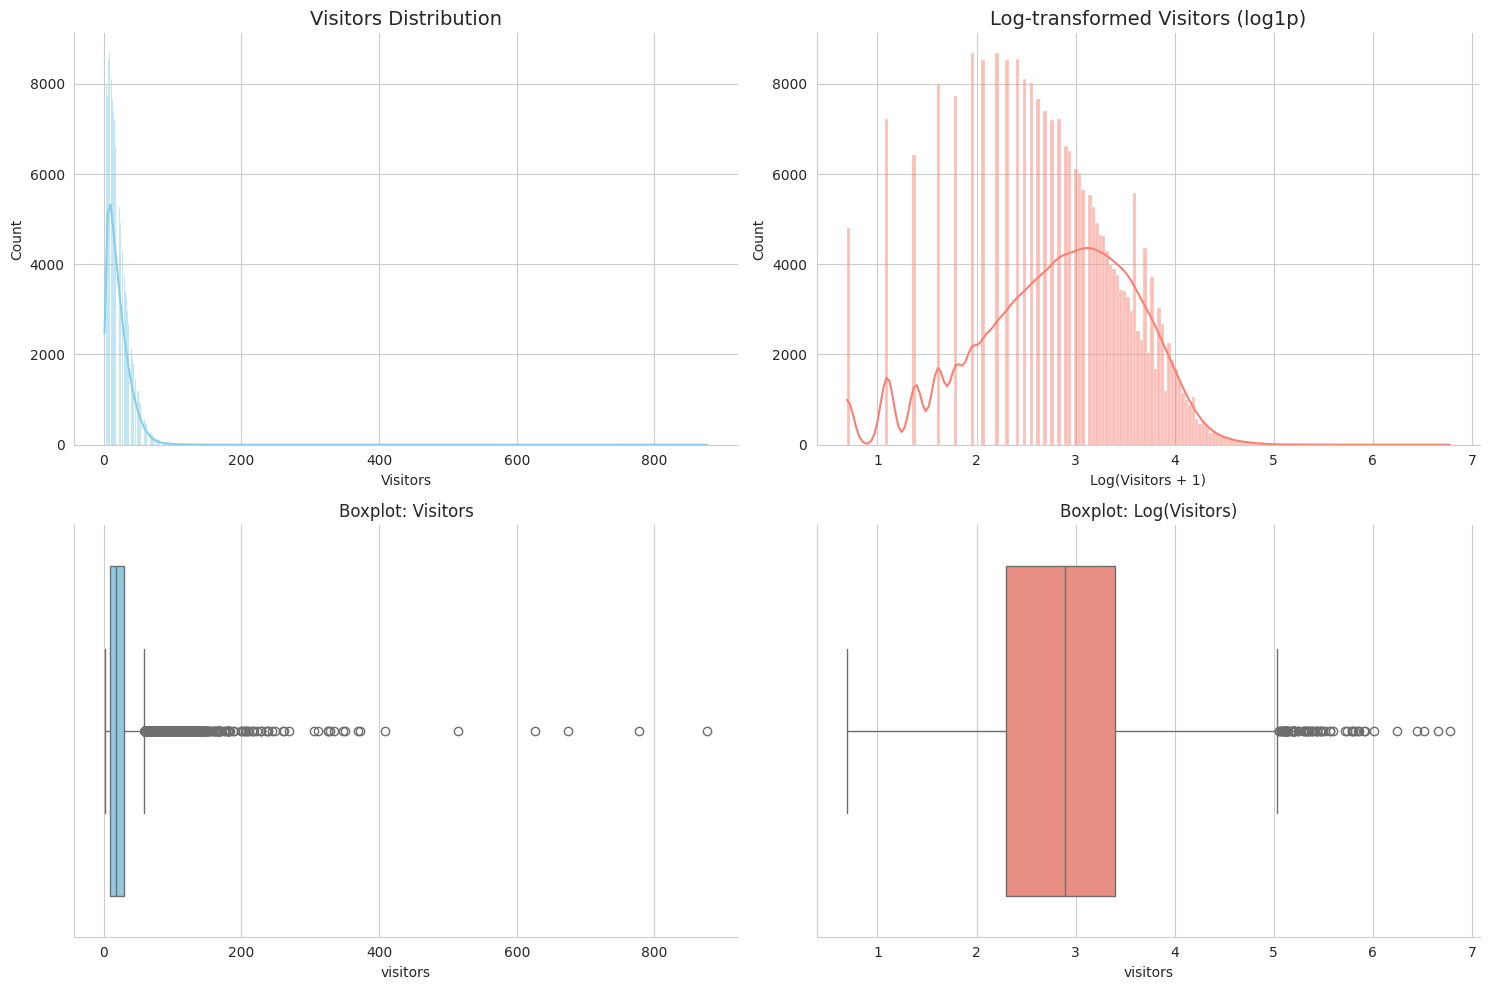

In [67]:
from restaurant_visitor_eda.plots import plot_target_distribution

plot_target_distribution(df_air_visit_data)

### Target value stats: (given and logarithmized)

In [68]:
from restaurant_visitor_eda.dataset import get_stats

get_stats(pd.DataFrame(df_air_visit_data['visitors']))

,visitors
count,252108.000
mean,20.974
std,16.757
min,1.000
25%,9.000
50%,17.000
75%,29.000
95%,52.000
99%,73.000
max,877.000


In [69]:
get_stats(pd.DataFrame(np.log1p(df_air_visit_data['visitors'])))

,visitors
count,252108.000
mean,2.803
std,0.808
min,0.693
25%,2.303
50%,2.890
75%,3.401
95%,3.970
99%,4.304
max,6.778


### Key Insights:

1. **Heavy Right Tail (Heavy Right skewness):** The given __visitors__ distribution is heavily right-skewed. The median number of daily visitors is **17**, while the mean is **~21**.

2. **Extreme outliers (which cause the tail):** While the **99th percentile** is **73**, the **maximum** is **877**. This explains, why the right tail and skewness have appeared. These values might not be particularly **outliers** in terms of mistake in the data, but rather unusual events, such as large weddings, corporate banquents, food festivals and etc.

3. **Transforming the value:** applying logarithmization `np.log1p` to the value, smoothes the large right tail and forces its distribution to become closer to a normal (Gaussian) bell-like curve

4. **Initial error:** The target loss function from the Kaggle competition is `RMSLE` = $\sqrt{\frac{1}{n} \sum{(\log (p_i + 1) - \log (a_i + 1))^2}}$, this clearly gives us a hint that **insight №3** totally makes sense.


## 4. Features Analysis



In [70]:
from restaurant_visitor_eda.plots import build_categorical_count_plot

### 4.1 Restaurants' genres


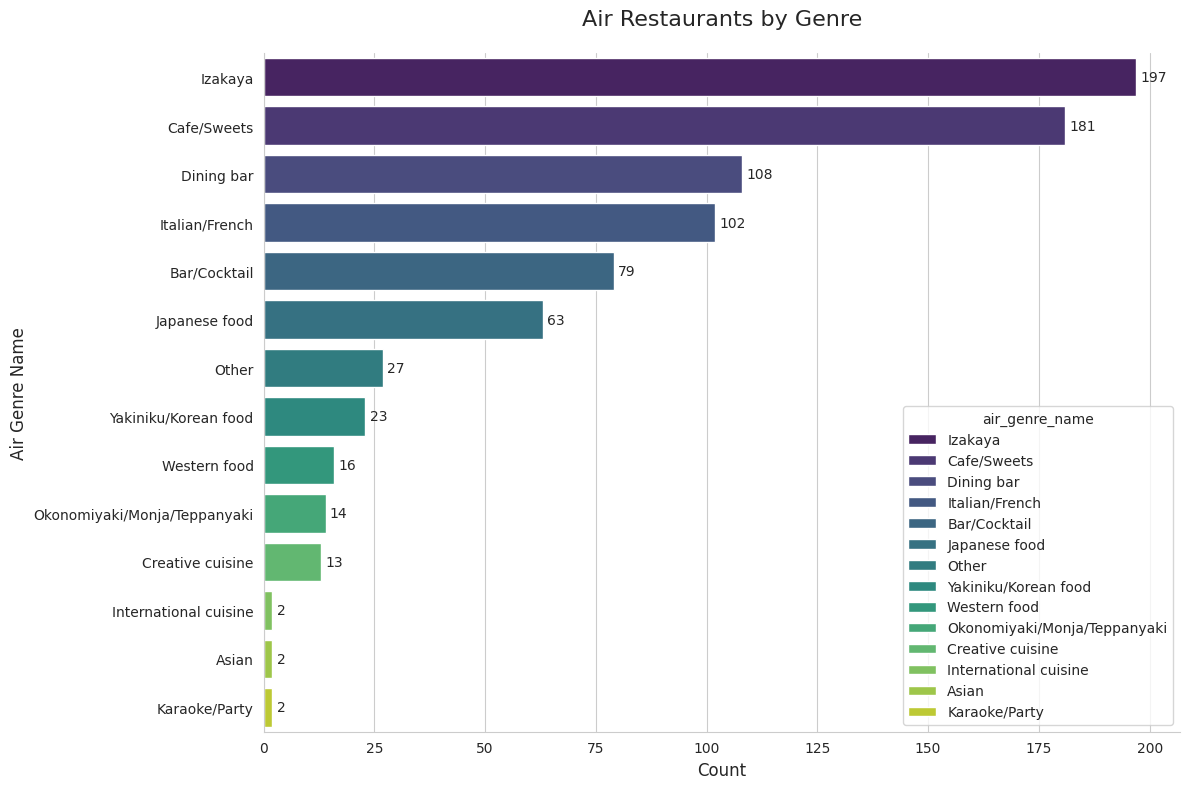

In [71]:
build_categorical_count_plot(df_air_store_info, 'air_genre_name', 'Air Restaurants by Genre')

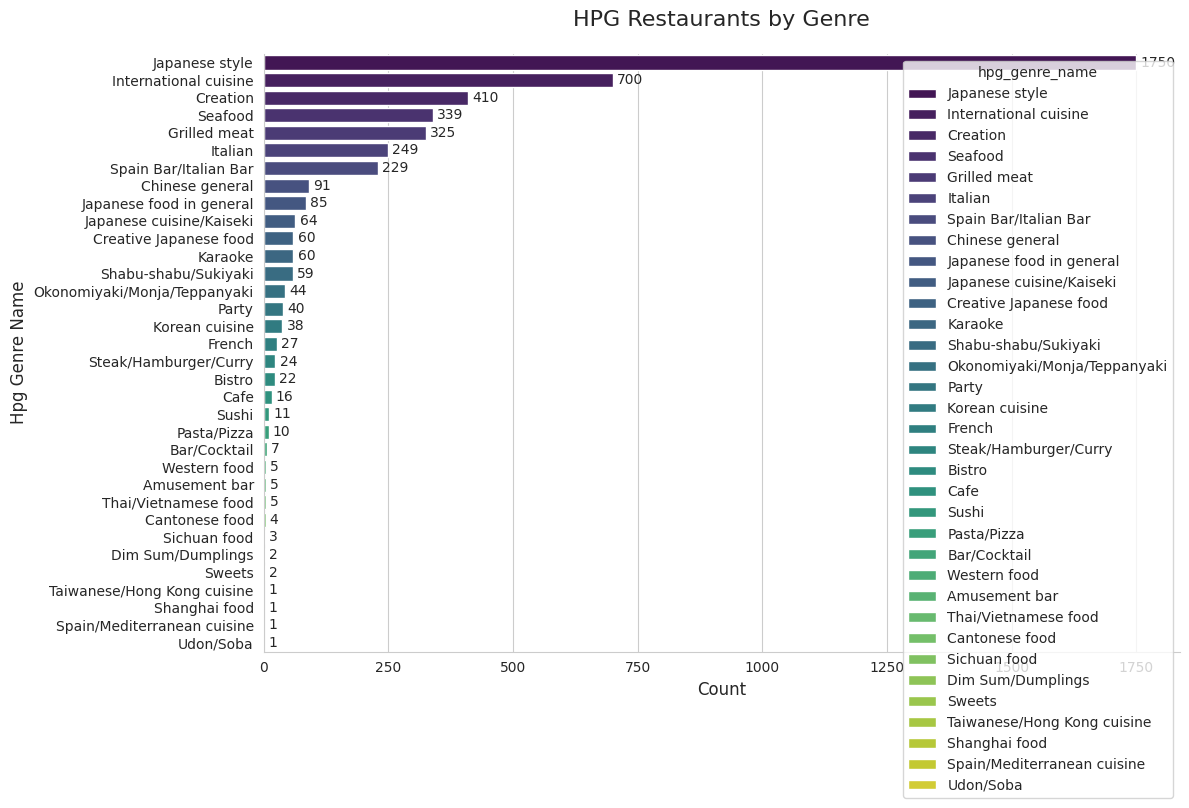

In [72]:
build_categorical_count_plot(df_hpg_store_info, 'hpg_genre_name', 'HPG Restaurants by Genre')

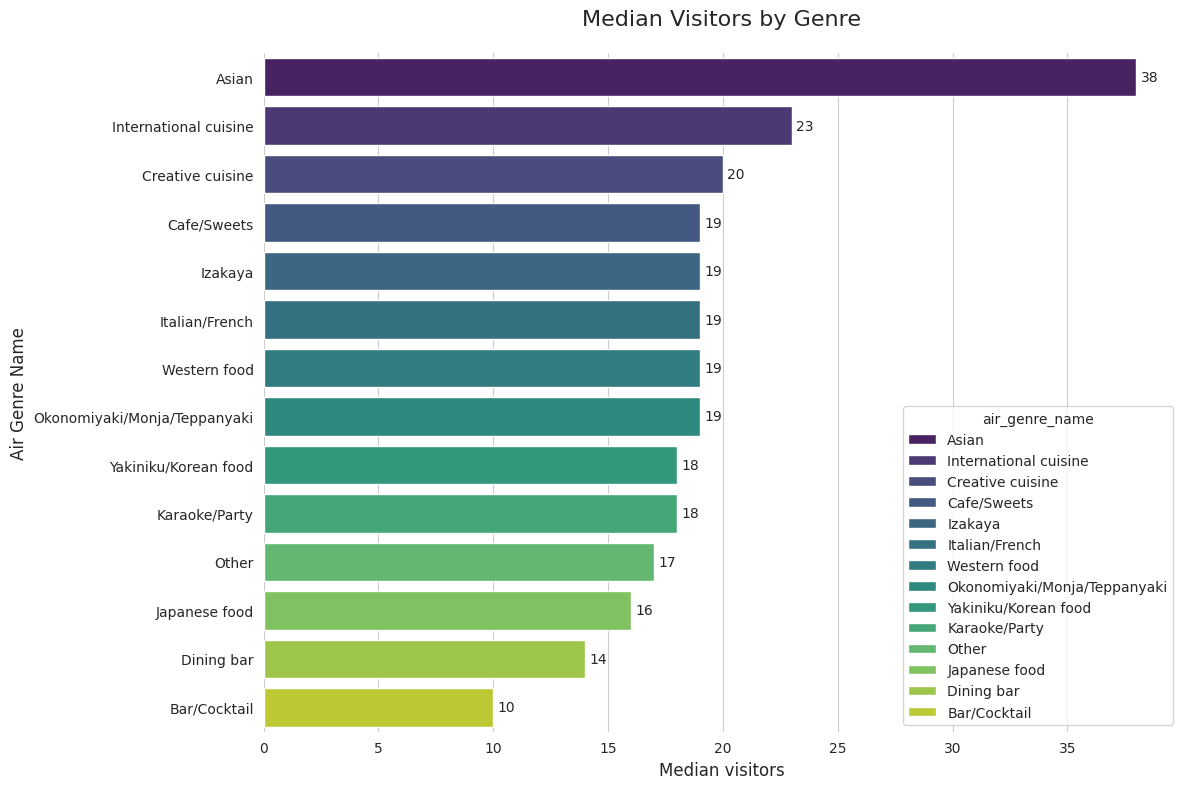

In [73]:
from restaurant_visitor_eda.plots import build_target_by_category_plot
df_joined = pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id')
build_target_by_category_plot(df_joined, 'air_genre_name', title='Median Visitors by Genre')

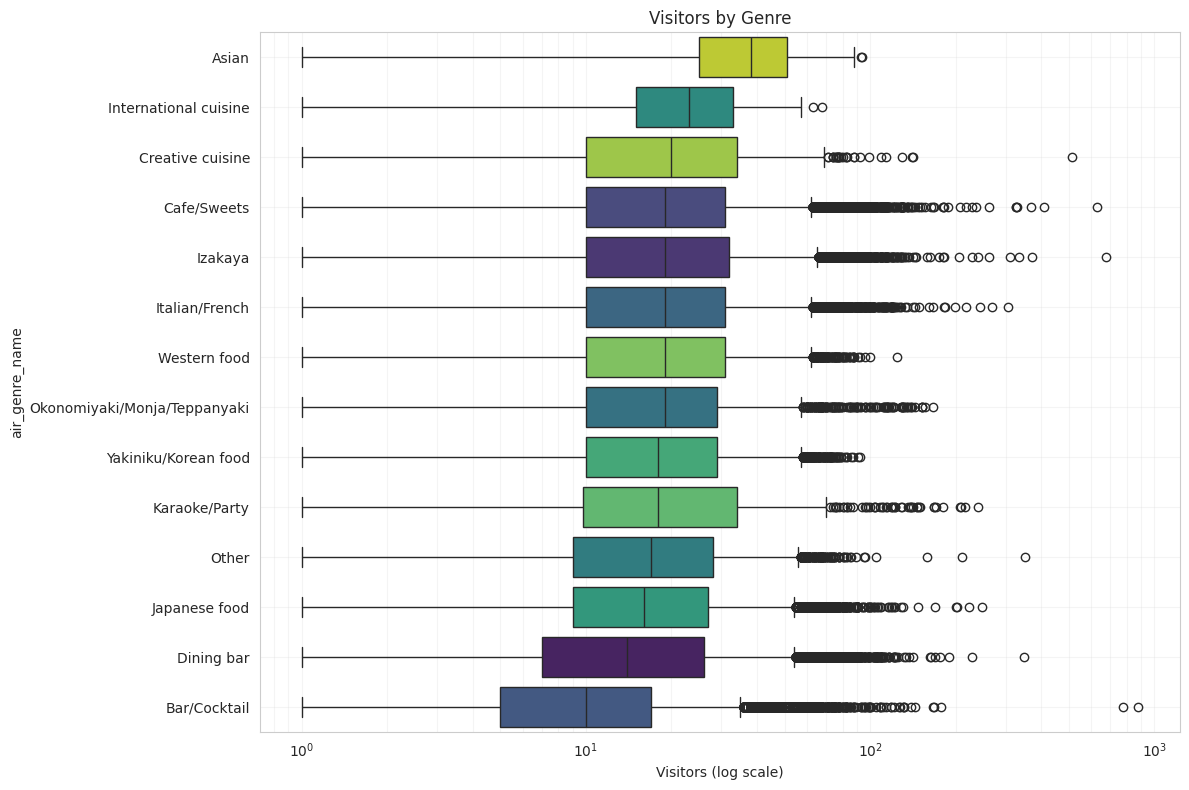

In [74]:
from restaurant_visitor_eda.plots import build_visitors_boxplot

build_visitors_boxplot(df_joined, y_col='air_genre_name', title="Visitors by Genre")

### Key Insights:

1. **Genres in AIR vs. HPG Systems:**
    *   In the **Air** system, **Izakaya** and **Cafe/Sweets** are the most common types.
    *   The **HPG** system shows a different distribution, with **Japanese style** and **International cuisine** being the dominant categories.
    *   This comparison does not bring anything meaningful, because the Systems might have put the same restaurants in different genres
2. **Popularity vs. Traffic:**
    *   The most common genres are not necessarily the most visited. While **Asian** food restaurants are few in number (only 2nd in the Air dataset), they have the highest **median daily visitors (~38)**.
    *   **International cuisine** and **Creative cuisine** also show higher-than-average traffic (~20-23 visitors).
    *   **Bar/Cocktail** places have the lowest median values **(~10)**

3. **Variance and Outliers:**
    *   The boxplots show large variance in all genres. All every categories have extreme outliers (100+ visitors), suggesting that **external factors** (holidays, weekends, local events) might have a stronger impact on attendance than the genre itself.
    *   The "Asian" genre has a very tight but high distribution, which might be a result of a small sample size (low number of such restaurants) rather than a general rule.

### 4.2. Geographic Distribution

The `air_area_name` column contains hierarchical information about the restaurant's location: (prefecture, district, block)

The `air_area_name` column will be splited into 3 new columns:

1. **Prefecture** 
2. **District**
3. **Block** 


In [75]:
df_air_store_info[['prefecture', 'district', 'block']] = df_air_store_info['air_area_name'].str.strip().str.split(' ', n=2, expand=True)


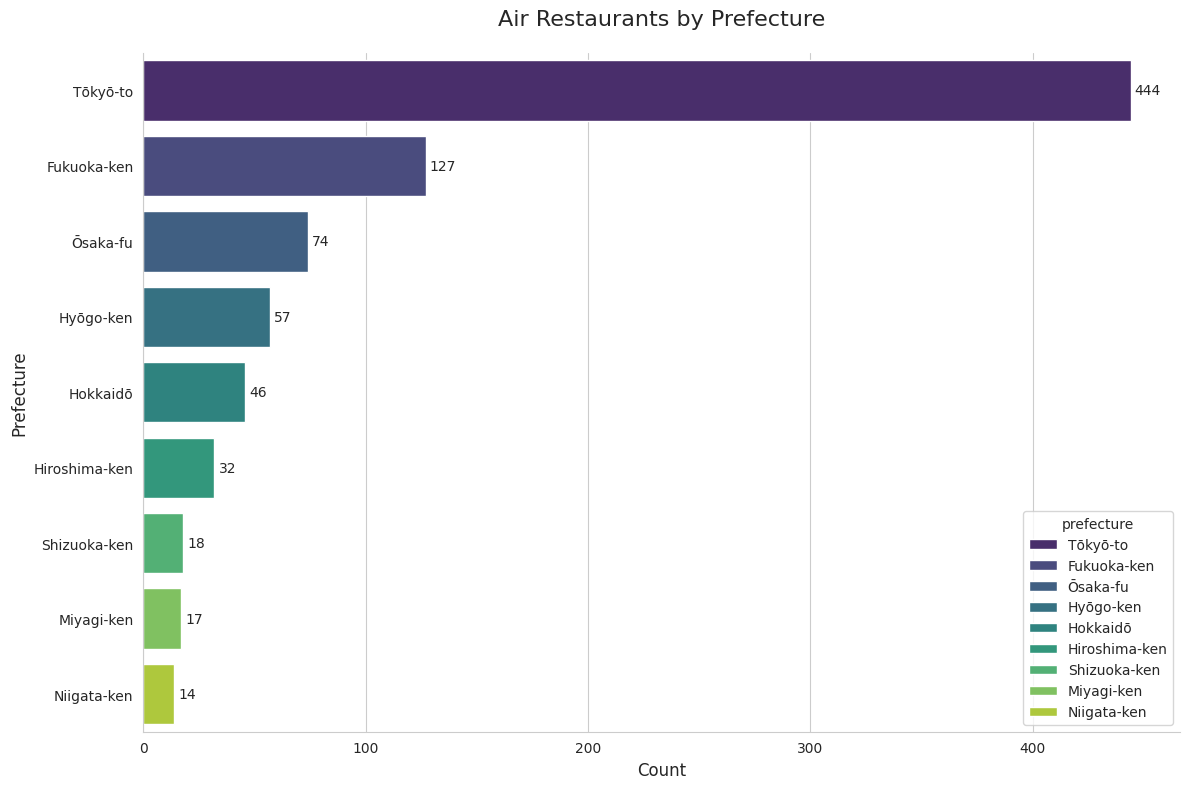

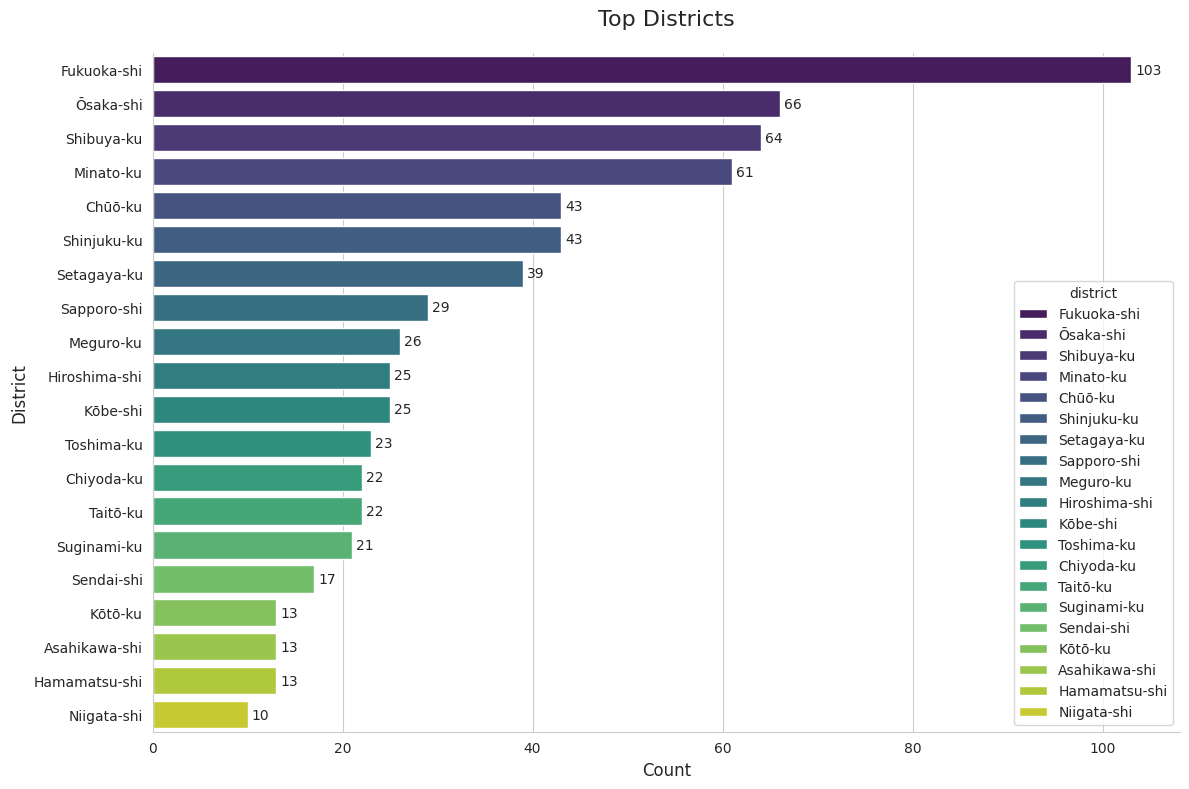

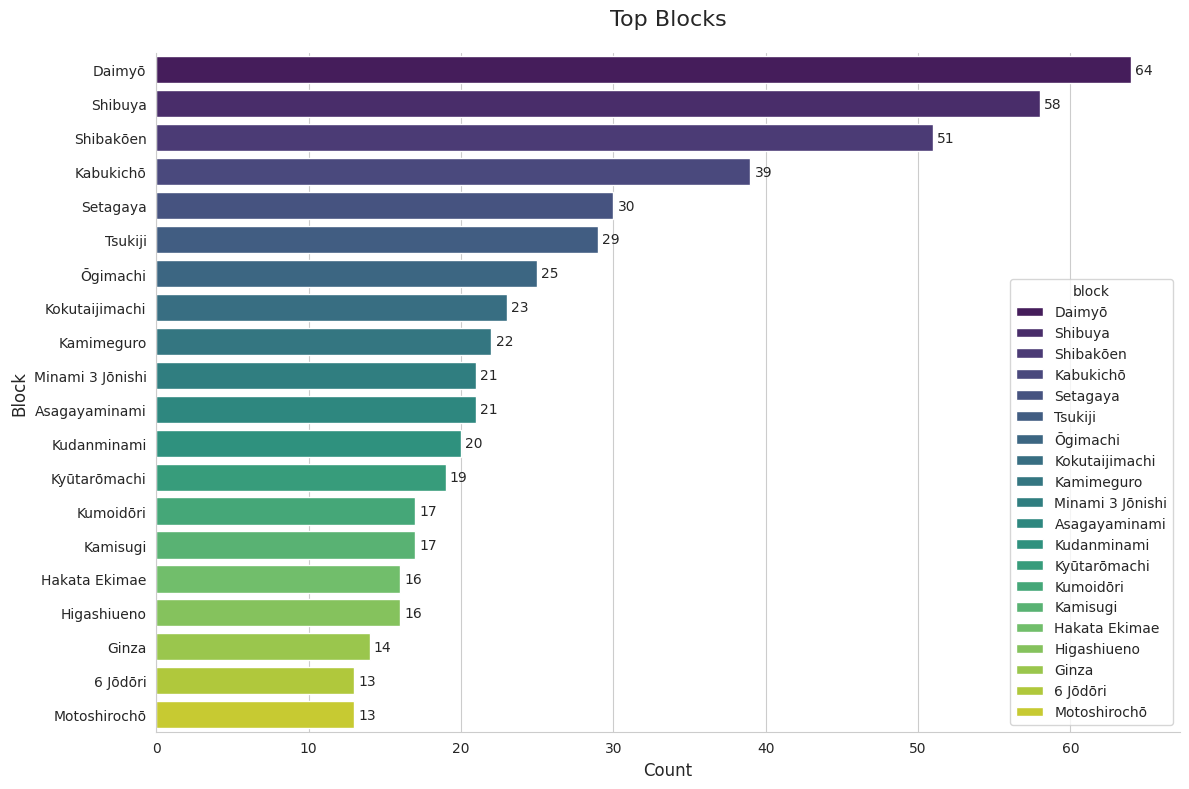

In [76]:
from restaurant_visitor_eda.plots import build_categorical_count_plot

build_categorical_count_plot(df_air_store_info, 'prefecture', 'Air Restaurants by Prefecture')
build_categorical_count_plot(df_air_store_info, 'district', 'Top Districts', top_n=20)
build_categorical_count_plot(df_air_store_info, 'block', 'Top Blocks', top_n=20)


### Key Insights:

1. **Tokyo Dominance:** The dataset is heavily biased towards **Tokyo-to**, which hosts **444** restaurants (more than half of the total `air` dataset). 
2. **Major Cities:** After Tokyo, the largest clusters are in **Fukuoka-ken** (127) and **Osaka-fu** (74). These are Japan's major economic centers, which likely share similar visitor patterns and holiday impacts.
4. **Districts and Blocks:** The `districts` and `blocks` columns have too many unique values, using them as a categorical features might lead to overfitting or data sparsity. In order to avoid this, we might have to use only these blocks and districts, that are heavily represented in the data set, while others unite in one new category __other__

### 4.3. Impact of Location on Restaurant Popularity

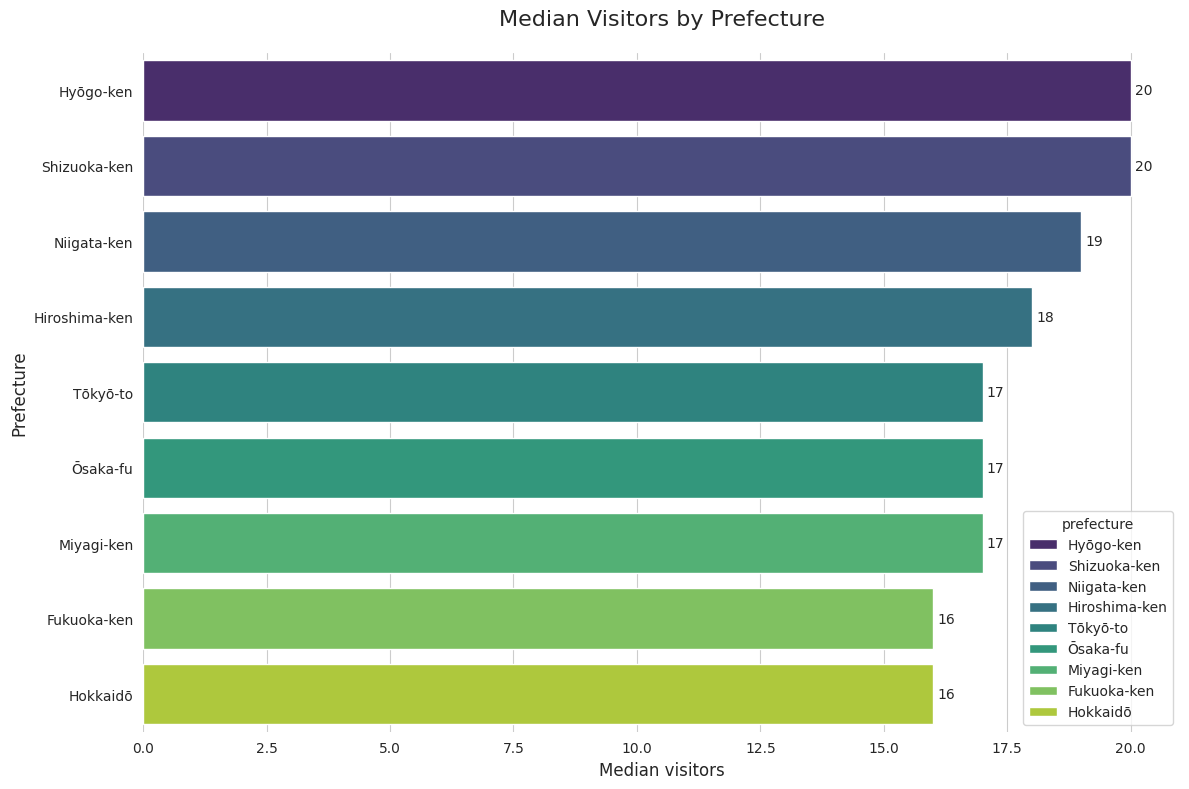

In [77]:
from restaurant_visitor_eda.plots import build_target_by_category_plot

df_joined = pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id')

build_target_by_category_plot(df_joined, 'prefecture', title='Median Visitors by Prefecture')

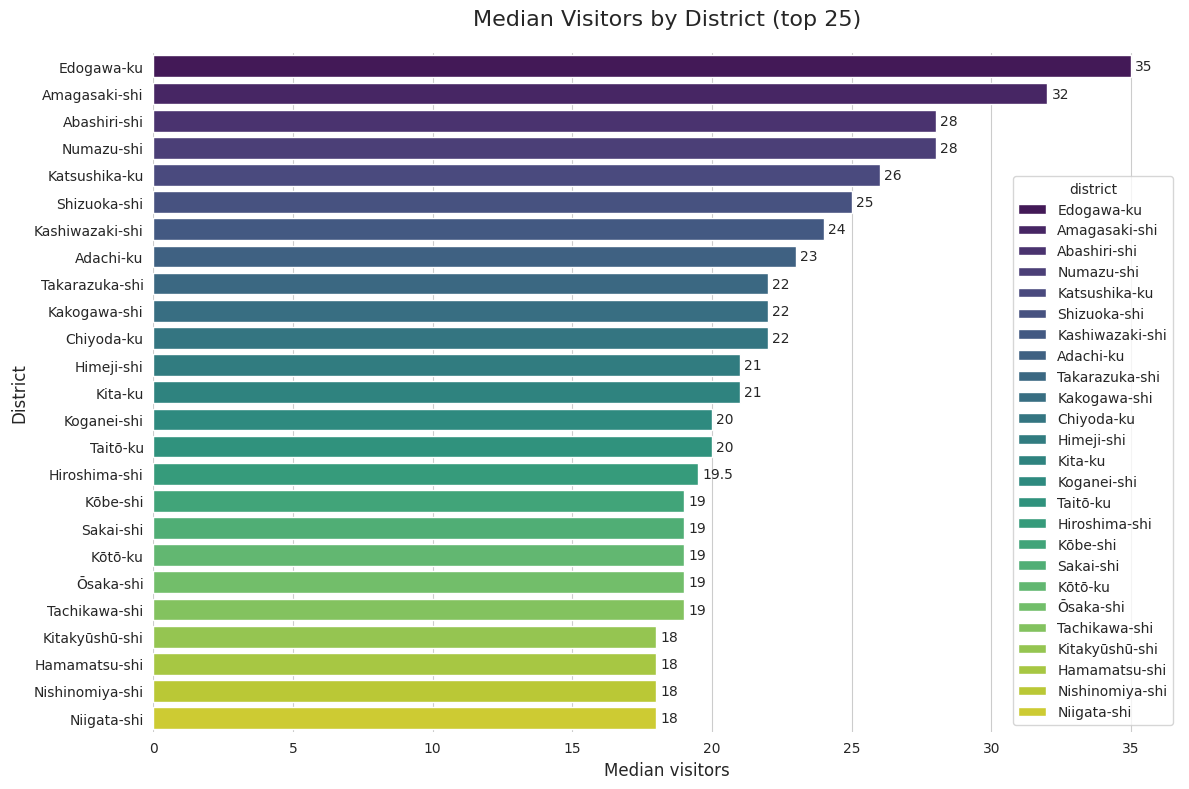

In [78]:
top = 25
build_target_by_category_plot(df_joined, 'district', title=f'Median Visitors by District (top {top})', top_n=top)

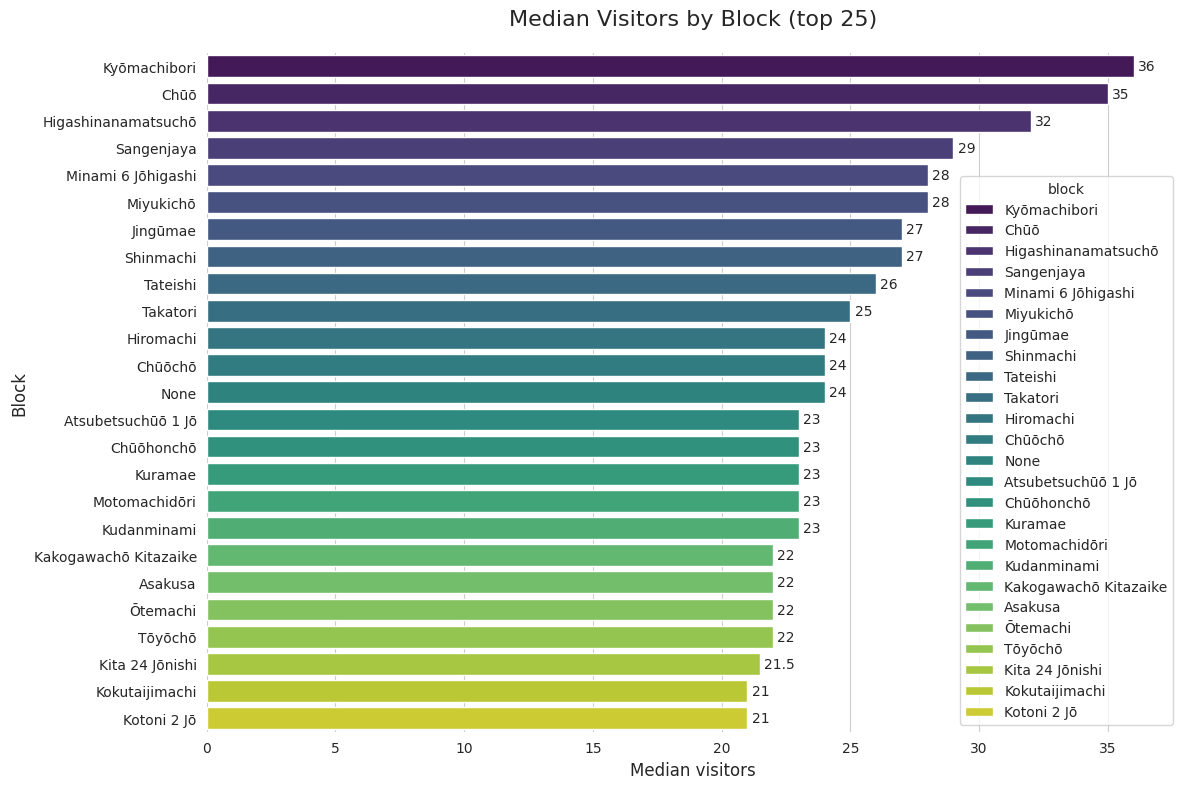

In [79]:
top = 25
build_target_by_category_plot(df_joined, 'block', title=f'Median Visitors by Block (top {top})', top_n=25)

### Key Insights: 

1. **Similar values at prefectures level:** The median number of visitors is quite consistent across different prefectures, ranging narrowly between **16 and 20**. While Tokyo has the most restaurants, it doesn't necessarily have the highest median traffic per venue (**17**), standing behind **Hyogo-ken** and **Shizuoka-ken** (**20**).
2. **High variance in Districts:** As we move to a deeper level (Districts), we see much higher variance. **Edogawa-ku** and **Amagasaki-shi** stand out with medians of **35** and **32** respectively, which is about 2 times higher than the average in the country. This suggests that certain specific urban environments or residential patterns (quality of life, price of accomodation and etc.) significantly boost restaurant attendance.
3. **Large varience (Blocks):** At the most deepest "Block" level, areas like **Kyōmachibori** and **Chūō** reach the highest median traffic (**35–36**). 
4. **Overfitting:** As it has been mentioned before, the geographical location of the venue might be a usefule feature, however, if we use all of them, it might lead to data sparsity and overfitting. We should consider only the most popular ones.

### 4.4.  Genre and Location Interaction



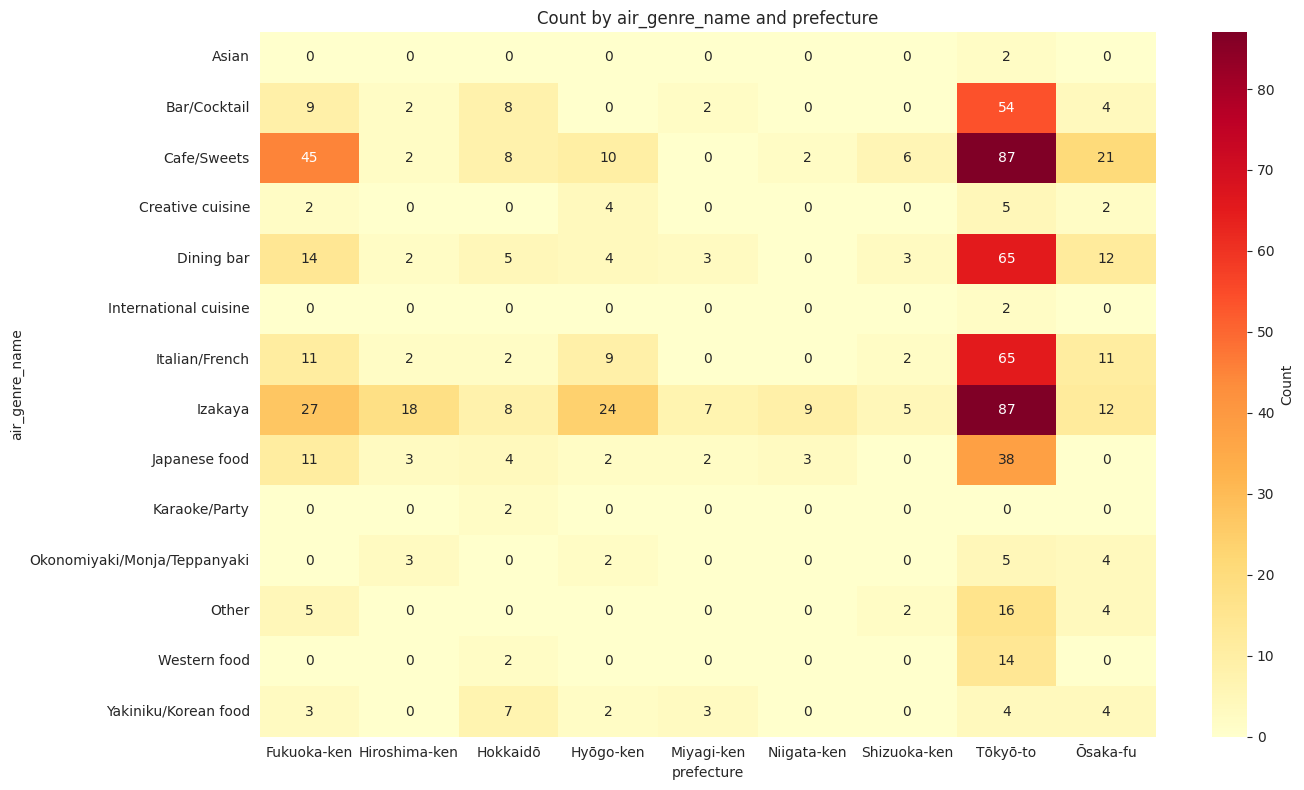

In [80]:
from restaurant_visitor_eda.plots import plot_heatmap

plot_heatmap(df_air_store_info, index='air_genre_name', columns='prefecture', agg_func='count')

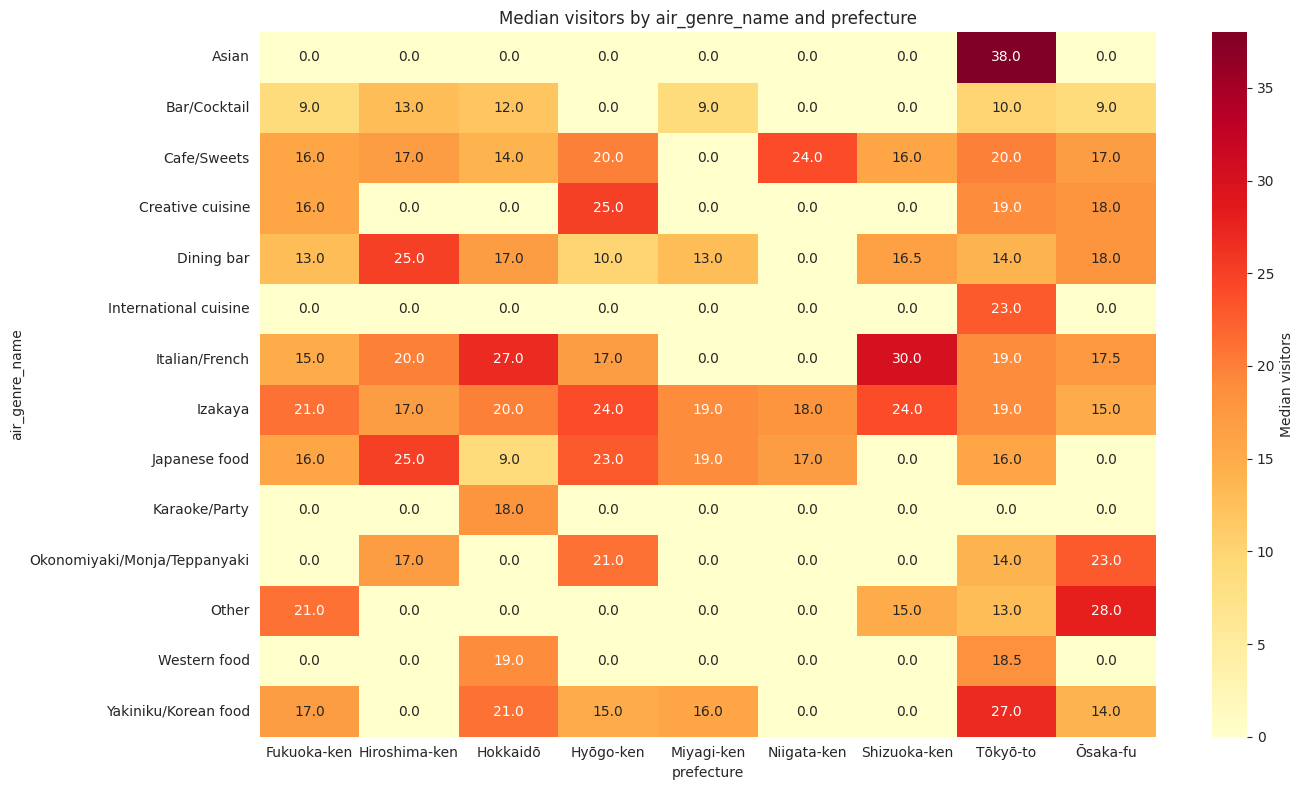

In [81]:
plot_heatmap(
    pd.merge(df_air_visit_data, df_air_store_info, on='air_store_id'), 
    index='air_genre_name', 
    columns='prefecture', 
    agg_func='median'
)

### Key Insights:

1. **Genres Representation on different regions:** 
    *   **Tokyo** is the only prefecture that covers almost the entire spectrum of genres, including niche categories like **Asian** and **International cuisine**.
    *   **Fukuoka-ken** shows a strong focus on **Cafe/Sweets** (45 restaurants).

2. **The "Big Fish in a Small Pond" Effect:** 
    *   While Tokyo has the highest volume of restaurants, it rarely has the highest median visitor counts per genre. 
    *   For instance, **Italian/French** restaurants in **Shizuoka-ken** and **Hokkaido** have much higher medians (**30** and **27**) compared to Tokyo (**19**). This suggests that in certain regions, specific genres might face less competition or higher local demand.

3. **Data Sparsity and Reliability:** 
    *   The high median of **38** for **Asian food in Tokyo** should be treated with caution, as it is based on only **2 restaurants**. 
    *   Many cells in the visitor heatmap are empty (zero or yellow), indicating that some genre-prefecture combinations are missing entirely. This confirms that we should be careful with high-cardinality feature interactions to avoid overfitting.

## 5. Time-Series 

We will look into several things in the data set:
1.  **Weekly Seasonality:** How traffic changes across different days of the week.
2.  **Holiday Impact:** Whether official holidays lead to a statistically significant increase in visitors.
3.  **The "Eve" Effect:** The behavior of customers on the nights preceding holidays.

In [82]:
df_air_visit_data['visit_datetime'] = pd.to_datetime(df_air_visit_data['visit_date'])

In [83]:
df_date_info['date'] = pd.to_datetime(df_date_info['calendar_date'])
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_date_info['day_of_week'] = pd.Categorical(df_date_info['day_of_week'], categories=days_order, ordered=True)

In [84]:
df_joined_for_day_of_week_holidays = pd.merge(df_air_visit_data, df_date_info, left_on='visit_datetime', right_on='date')
df_joined_for_day_of_week_holidays

,air_store_id,visit_date,visitors,visitors_log,visit_datetime,calendar_date,day_of_week,holiday_flg,date
0,air_ba937bf13d40fb24,2016-01-13,25,3.258097,2016-01-13,2016-01-13,Wednesday,0,2016-01-13
1,air_ba937bf13d40fb24,2016-01-14,32,3.496508,2016-01-14,2016-01-14,Thursday,0,2016-01-14
2,air_ba937bf13d40fb24,2016-01-15,29,3.401197,2016-01-15,2016-01-15,Friday,0,2016-01-15
3,air_ba937bf13d40fb24,2016-01-16,22,3.135494,2016-01-16,2016-01-16,Saturday,0,2016-01-16
4,air_ba937bf13d40fb24,2016-01-18,6,1.945910,2016-01-18,2016-01-18,Monday,0,2016-01-18
...,...,...,...,...,...,...,...,...,...
252103,air_24e8414b9b07decb,2017-04-18,6,1.945910,2017-04-18,2017-04-18,Tuesday,0,2017-04-18
252104,air_24e8414b9b07decb,2017-04-19,6,1.945910,2017-04-19,2017-04-19,Wednesday,0,2017-04-19
252105,air_24e8414b9b07decb,2017-04-20,7,2.079442,2017-04-20,2017-04-20,Thursday,0,2017-04-20
252106,air_24e8414b9b07decb,2017-04-21,8,2.197225,2017-04-21,2017-04-21,Friday,0,2017-04-21


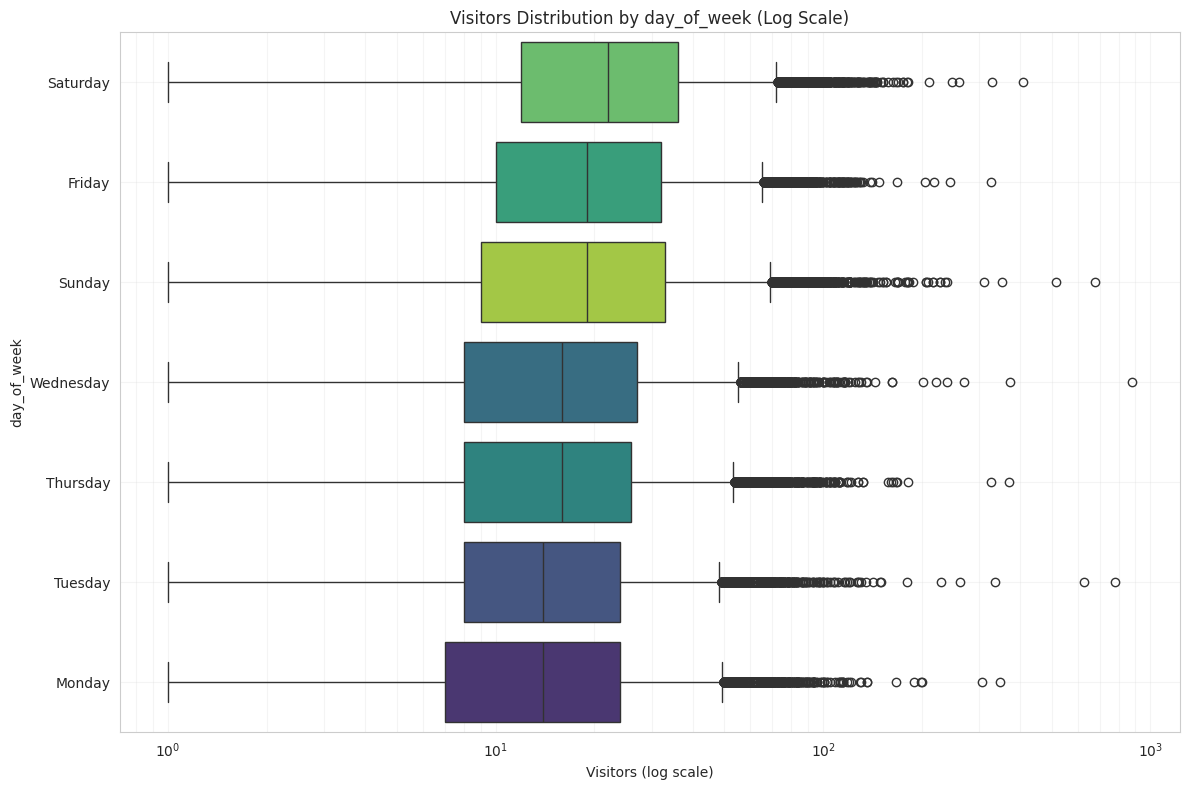

In [85]:
build_visitors_boxplot(df_joined_for_day_of_week_holidays, y_col='day_of_week')

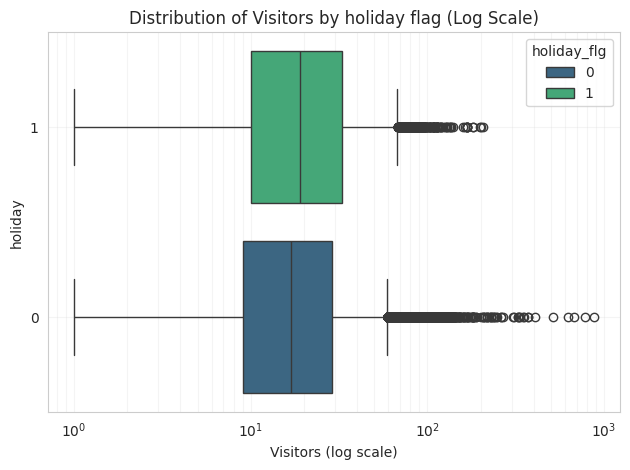

In [86]:
from restaurant_visitor_eda.plots import plot_visitors_boxplot_air_by_holiday

plot_visitors_boxplot_air_by_holiday(df_joined_for_day_of_week_holidays)

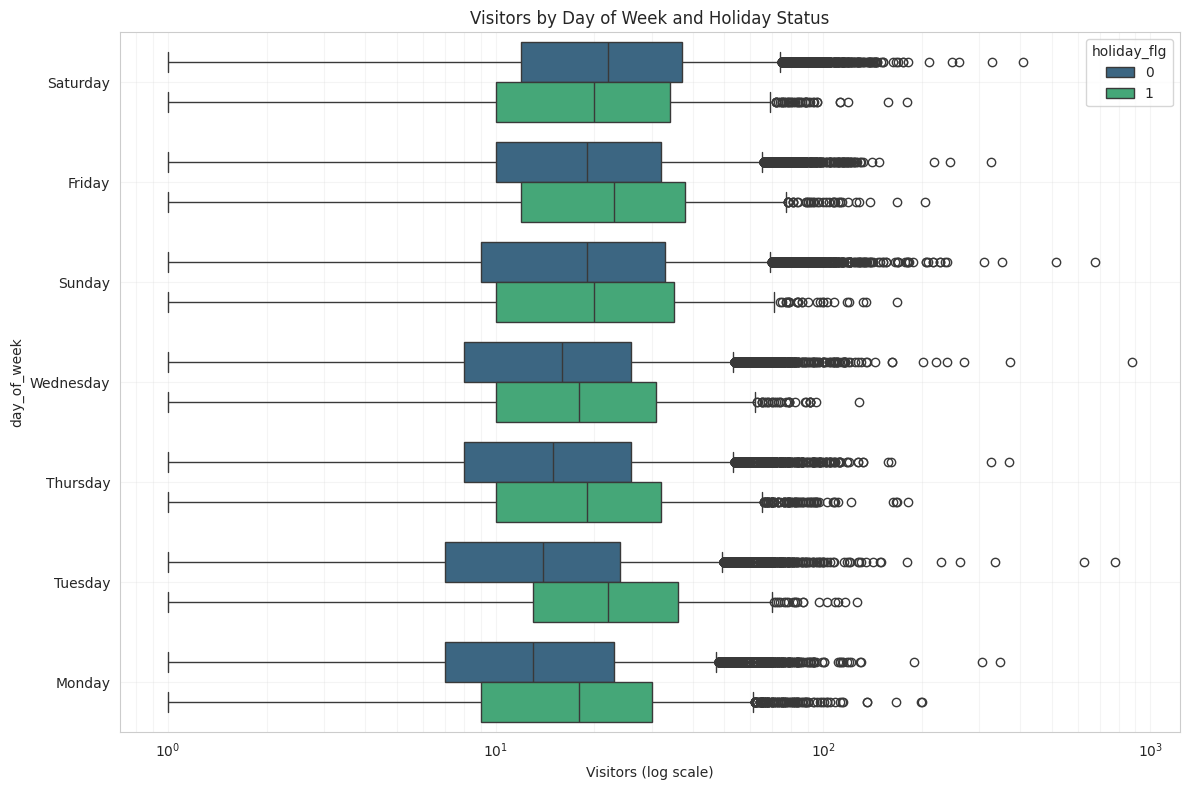

In [87]:
build_visitors_boxplot(
    df_joined_for_day_of_week_holidays, 
    y_col='day_of_week', 
    hue_col='holiday_flg',
    title="Visitors by Day of Week and Holiday Status"
)

#### Statistical Validation of Holiday Impact
To confirm that the difference between workdays and holidays is not accidental, we perform a non-parametric statistical test (Mann-Whitney U test) on the visitor distributions.

In [88]:
from restaurant_visitor_eda.dataset import calculate_holiday_significance

calculate_holiday_significance(df_joined_for_day_of_week_holidays)

Statistic: 1653389061.50
P-value: 0.0000000000
Result: The difference is significant.


In [89]:
df_joined_for_day_of_week_holidays.sort_values(by='date', ascending=True, inplace=True)

In [ ]:
import numpy as np

df_date_info = df_date_info.sort_values('calendar_date')
df_date_info['next_is_holiday'] = df_date_info['holiday_flg'].shift(-1).fillna(0).astype(int)
df_date_info['is_weekend'] = df_date_info['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

df_date_info['is_off_day'] = (
    (df_date_info['holiday_flg'] == 1) | 
    (df_date_info['is_weekend'] == 1)
).astype(int)

df_date_info['next_is_off_day'] = df_date_info['is_off_day'].shift(-1).fillna(0).astype(int)

conditions = [
    (df_date_info['is_off_day'] == 1) & (df_date_info['next_is_off_day'] == 1), 
    (df_date_info['is_off_day'] == 1) & (df_date_info['next_is_off_day'] == 0), 
    (df_date_info['is_off_day'] == 0) & (df_date_info['next_is_off_day'] == 1), 
    (df_date_info['is_off_day'] == 0) & (df_date_info['next_is_off_day'] == 0)  
]

choices = [
    'Off-day & Off-day', 
    'Off-day & Workday',
    'Workday & Off-day', 
    'Workday & Workday'
]

df_date_info['day_pattern'] = np.select(conditions, choices, default='Unknown')

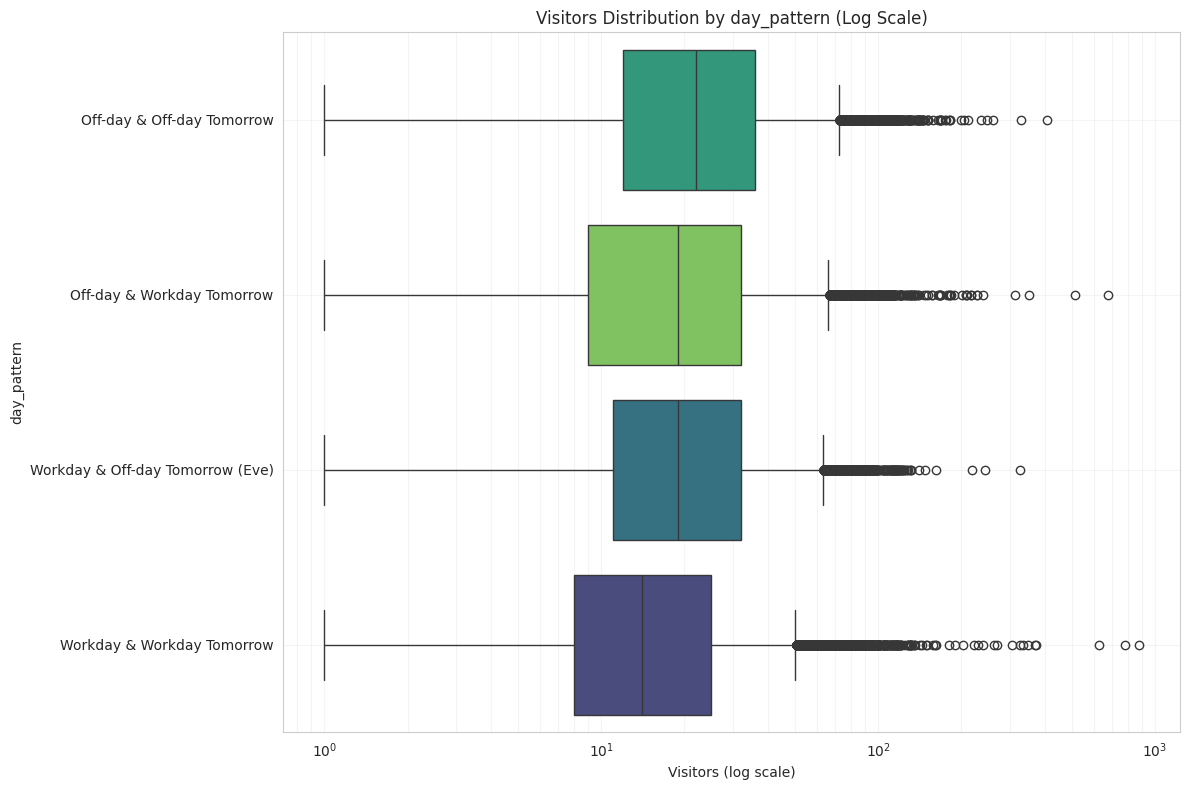

In [97]:
df_final = pd.merge(
    df_air_visit_data, 
    df_date_info, 
    left_on='visit_date', 
    right_on='calendar_date',
    how='left'
)

build_visitors_boxplot(df_final, y_col='day_pattern')

### Key insights:

1.  **Weekly Cycles:** There is a clear weekly seasonality. **Saturday** is the busiest day of the week, followed by **Friday** and **Sunday**. **Monday** and **Tuesday** consistently show the lowest median visitor counts.
2.  **Proven Holiday Effect:** The statistical test returned a **p-value of 0.00**, this confirms that holidays have a significant impact on visitor traffic.
3.  **Interaction between Holidays and Weekdays:** 
    *   A holiday occurring on a typical workday (e.g., Monday or Tuesday) significantly boosts traffic compared to a regular Monday.
    *   On weekends, the holiday effect is less pronounced because traffic is already high, but it still helps maintain peak numbers.
4.  **The "Eve" Discovery (Workday & Holiday Tomorrow):** 
    *   **Peak Demand:** The highest visitor counts consistently occur during **"Off-day & Off-day Tomorrow"** sequences (e.g., Saturdays or mid-holiday periods). This represents the absolute peak capacity for the restaurants in the dataset. 
    *   This is logically consistent: people are more likely to dine out when they don't have to work the following day. 
5. **The "Eve" vs. "Sunday" Parity:** A crucial discovery is that the median traffic for **"Workday & Off-day Tomorrow (Eve)"** (e.g., Fridays or the eve of a holiday) is nearly identical to **"Off-day & Workday Tomorrow"** (e.g., Sundays or the last day of a holiday). This suggests that the "anticipation effect" drives restaurant visits just as effectively as the holiday itself.

### 5.2. Long-term trends in the number of visitors

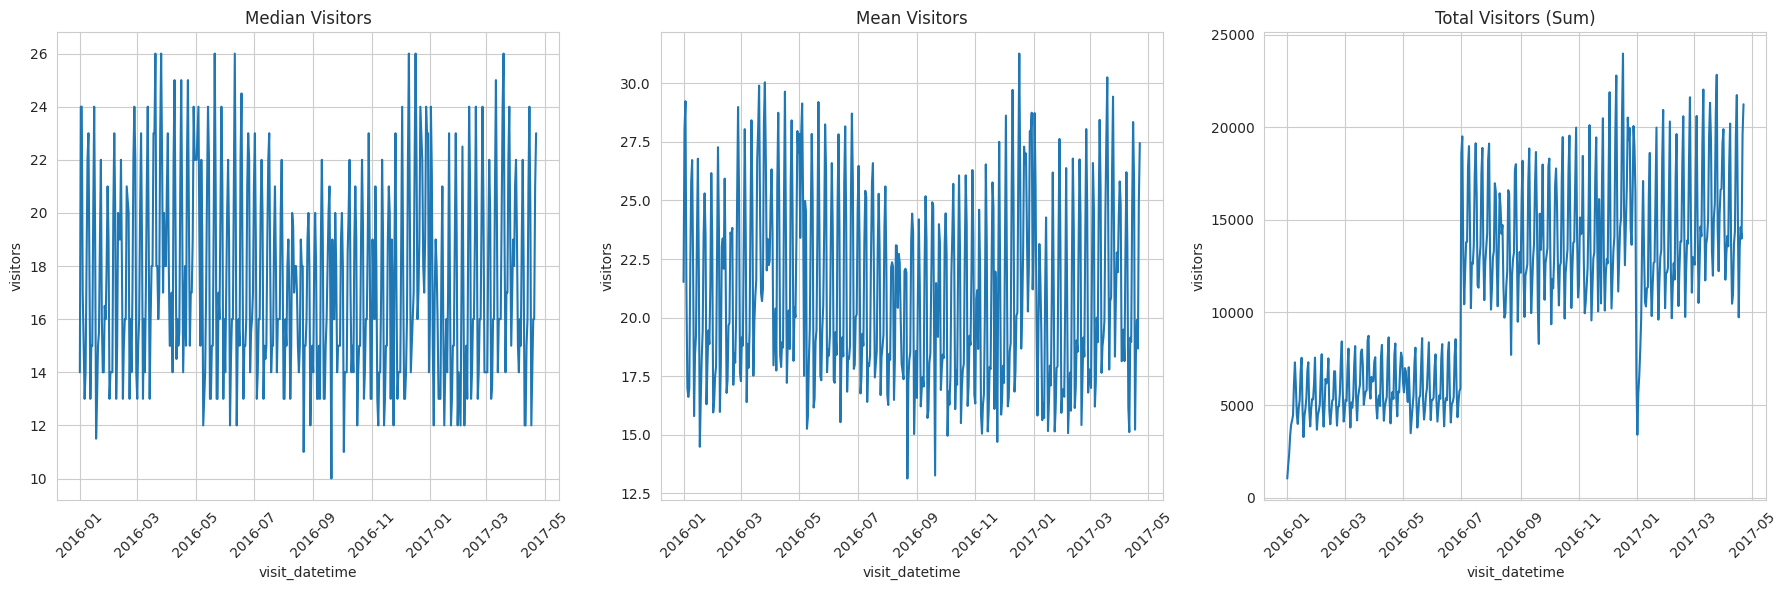

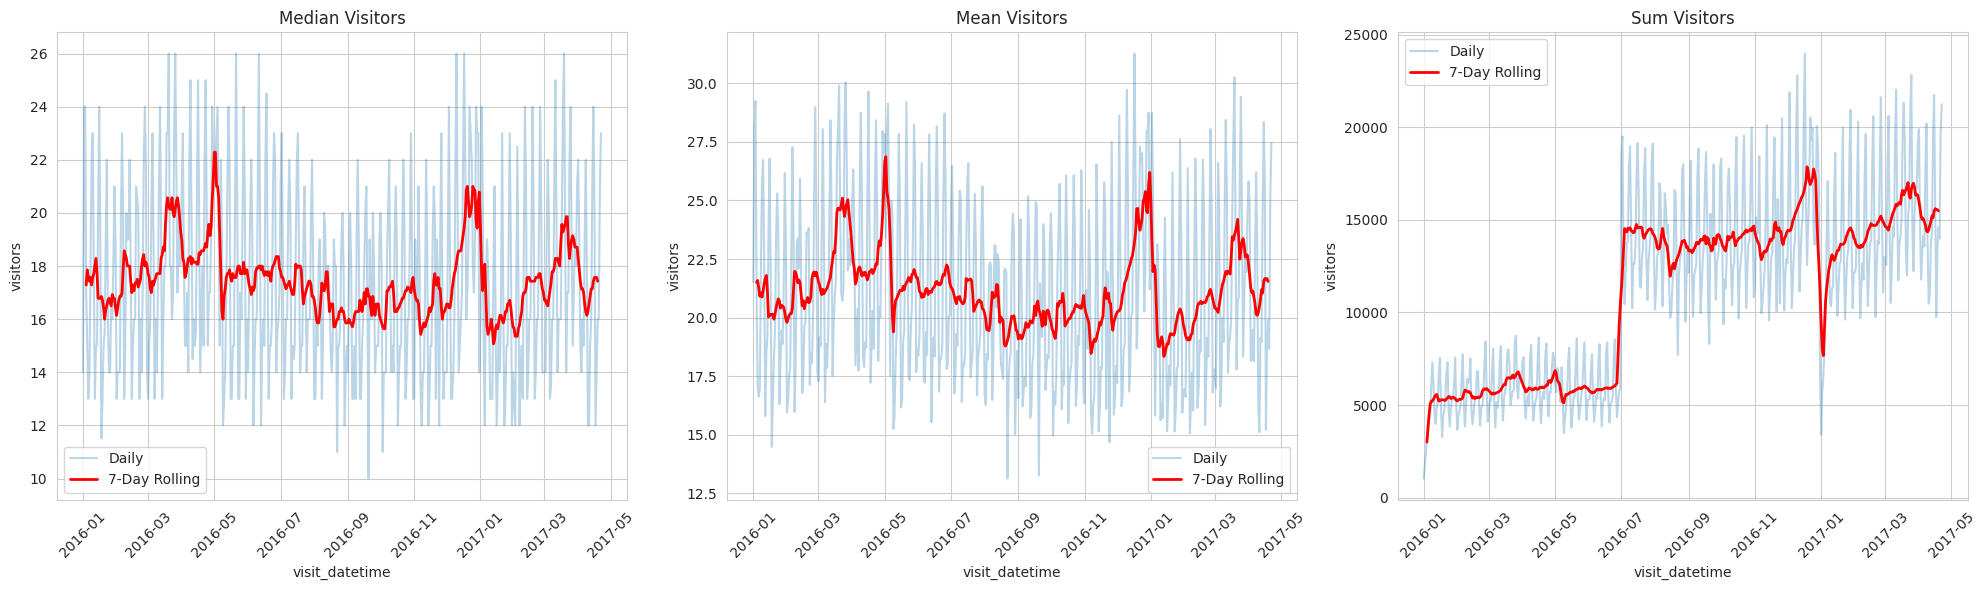

In [92]:
from restaurant_visitor_eda.plots import plot_visitors_over_year, plot_visitors_with_rolling

plot_visitors_over_year(df=df_joined_for_day_of_week_holidays)
plot_visitors_with_rolling(df=df_joined_for_day_of_week_holidays)

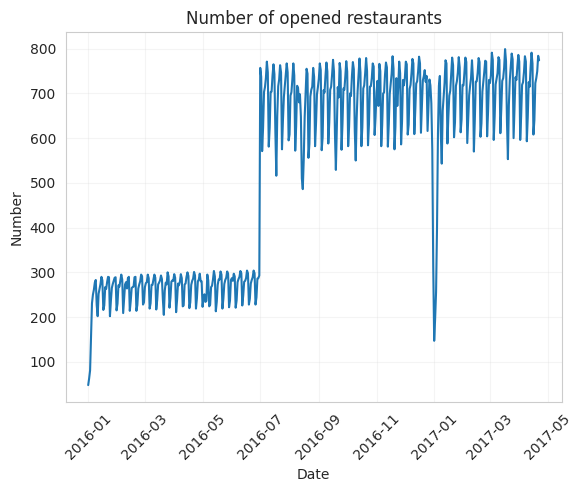

In [93]:
from restaurant_visitor_eda.plots import plot_number_of_open_restaurants

plot_number_of_open_restaurants(df=df_joined_for_day_of_week_holidays)

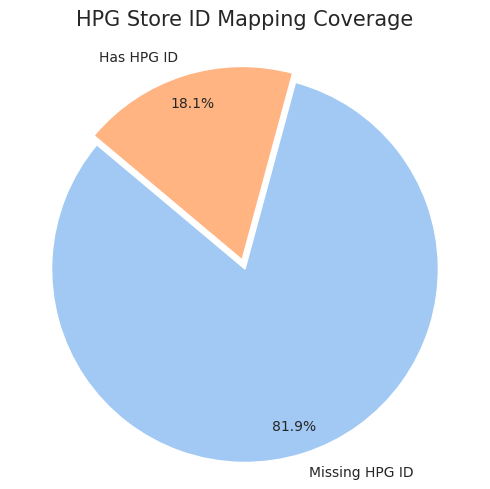

In [94]:
from restaurant_visitor_eda.plots import plot_hpg_coverage

plot_hpg_coverage(pd.merge(left=df_air_store_info, right=df_store_id_relation, on='air_store_id', how='left'))

### Key Insights:

1.  **The July 2016 Anomaly:** 
    *   The "Total Visitors" and "Number of Opened Restaurants" charts show a massive jump in **July 2016**. 
    *   The number of restaurants being tracked increased from ~300 to ~800 almost overnight. 
    *   **Conclusion:** This is not a growth of the restaurant market, but a point where a large data set of new restaurants was added to the Air system.

2.  **Christmas and New-Year holidays:**
    *   A sharp, deep valley is visible at the very end of 2016 and the beginning of January 2017. 
    *   This corresponds to the Japanese New Year holidays, when many businesses close. The "Number of opened restaurants" also drops, showing that many venues are closed during this period of time

3.  **7-Day Rolling Window Stability:**
    *   The 7-day rolling average (red line) shows that despite the July 2016 jump in *total* volume, the *median* and *mean* visitors per restaurant remained relatively stable throughout the year.

4.  **Limited AIR - HPG Linkage:**
    *   The pie chart confirms our initial hypothesis: only **18.1%** of AIR restaurants can be mapped to HPG IDs. 
  